In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
def drop_desc(df):
    desc_cols = [c for c in df.columns if c.startswith("DESC_")]
    return df.drop(columns=desc_cols, errors="ignore")

In [3]:
def clean_date(df, col, min_date, max_date):
    d = pd.to_datetime(df[col], format="%Y%m%d", errors="coerce")
    mask = (d < min_date) | (d > max_date)
    d[mask] = pd.NaT
    d = d.fillna(d.median())
    return d

In [4]:
def drop_rare_dummies_train_test(x_train, x_test, min_count=3):
    # colonne dummy = uint8 o bool
    rare_cols = [
        col for col in x_train.columns
        if (x_train[col].dtype in ["bool"]) and (x_train[col].sum() < min_count)
    ]
    
    # rimuovo SOLO dal train
    x_train = x_train.drop(columns=rare_cols)
    
    # rimuovo le stesse colonne dal test (se presenti)
    x_test = x_test.drop(columns=[c for c in rare_cols if c in x_test.columns])
    
    return x_train, x_test, rare_cols

In [5]:
def print_matrix(df):
    matrix = df.corr(numeric_only=True)
    plt.figure()
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.show()

In [6]:
def prepare_features(df):
    df = df.copy()

    # -----------------------------
    # 0. RIMOZIONE COLONNE STRETTAMENTE CORRELATE E IENTIFICATIVI UNIVOCI ORDINE
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_NUM", "VAL_COST"], errors="ignore")

    # -----------------------------
    # 1. ONE-HOT ENCODING
    # -----------------------------
    categorical_cols = [
        "ID_COMPANY", "IDS_ITEM", "ID_BUSINESS_LINE",
        "IDS_CUSTOMER", "ID_AREA_MANAGER", "ID_COUNTRY"
    ]

    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # -----------------------------
    # 2. RIMOZIONE COLONNE TESTUALI
    # -----------------------------
    df = drop_desc(df)

    # -----------------------------
    # 3. FEATURE TEMPORALI
    # -----------------------------
    df["ANNO"] = df["ID_ORDER_DATE"].dt.year
    df["TRIMESTRE"] = df["ID_ORDER_DATE"].dt.quarter
    df["MESE"] = df["ID_ORDER_DATE"].dt.month
    df["MESE_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)
    df["MESE_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.month / 12)

    df["SETTIMANA"] = df["ID_ORDER_DATE"].dt.isocalendar().week.astype(int)
    df["GIORNO_SETTIMANA"] = df["ID_ORDER_DATE"].dt.weekday
    df["GIORNO_SETTIMANA_SIN"] = np.sin(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["GIORNO_SETTIMANA_COS"] = np.cos(2 * np.pi * df["ID_ORDER_DATE"].dt.weekday / 7)
    df["WEEKEND"] = df["GIORNO_SETTIMANA"].isin([5,6]).astype(int)

    df["GIORNO"] = df["ID_ORDER_DATE"].dt.dayofyear
    df["GIORNO_SIN"] = np.sin(2 * np.pi * df["GIORNO"] / 365)
    df["GIORNO_COS"] = np.cos(2 * np.pi * df["GIORNO"] / 365)

    # -----------------------------
    # 4. RIMOZIONE DATE ORIGINALI
    # -----------------------------
    df = df.drop(columns=["ID_ORDER_DATE", "ID_INVOICE_DATE"], errors="ignore")

    return df

In [7]:
def make_forecast(start_date, end_date, df_old):
    """
    Genera forecast solo per le combinazioni cliente-item esistenti nello storico.
    e applica le feature temporali tramite prepare_features().
    NON allinea le colonne con il train.
    """

    # -----------------------------
    # 1. GENERO IL CALENDARIO FUTURO
    # -----------------------------
    future_dates = pd.date_range(start=start_date, end=end_date, freq="D")
    df_future = pd.DataFrame({"ID_ORDER_DATE": future_dates})

    # -----------------------------
    # 2. Estraggo combinazioni reali cliente-item-company-line-area-country
    # -----------------------------
    dims = df_old[[
        "ID_COMPANY",
        "IDS_ITEM",
        "ID_BUSINESS_LINE",
        "IDS_CUSTOMER",
        "ID_AREA_MANAGER",
        "ID_COUNTRY"
    ]].drop_duplicates()

    df_future = df_future.merge(dims, how="cross")

    # -----------------------------
    # 3. APPLICO LE FEATURE (prepare_features)
    # -----------------------------
    df_future = prepare_features(df_future)

    # -----------------------------
    # 4. RESTITUISCO IL DATAFRAME FUTURO
    # -----------------------------
    return df_future

In [8]:
def plot_trend(df, revenue_col="VAL_REVENUES"):
    df = df.copy()

    # Media per mese *e per anno*
    trend = df.groupby(["ANNO", "MESE"])[revenue_col].mean().reset_index()

    plt.figure(figsize=(12,5))

    # Una linea per ogni anno
    for anno in trend["ANNO"].unique():
        subset = trend[trend["ANNO"] == anno]
        plt.plot(
            subset["MESE"],
            subset[revenue_col],
            marker="o",
            linewidth=2,
            label=str(anno)
        )

    # Scala Y uniforme
    plt.ylim(25000, 45000)

    plt.xticks(ticks=range(1,13), labels=[str(m).zfill(2) for m in range(1,13)])
    plt.title("Andamento mensile della revenue (per anno)")
    plt.xlabel("Mese")
    plt.ylabel("Revenue media")
    plt.legend()
    plt.show()

# -----------------------------
# 1. CARICAMENTO E MERGE DATI
# -----------------------------

In [9]:
df_sales = pd.read_csv("SALES.csv")
df_company = pd.read_csv("COMPANY_LOOKUP.csv").drop_duplicates()
df_items = pd.read_csv("ITEM_LOOKUP.csv").drop_duplicates()
df_lines = pd.read_csv("ITEM_BUSINESS_LINE_LOOKUP.csv").drop_duplicates()
df_customers = pd.read_csv("CUSTOMER_LOOKUP.csv").drop_duplicates()
df_area = pd.read_csv("AREA_MANAGER_LOOKUP.csv").drop_duplicates()

df = df_sales.merge(df_company, on="ID_COMPANY", how="left")
df = df.merge(df_items, on="IDS_ITEM", how="left")
df = df.merge(df_lines, on="ID_BUSINESS_LINE", how="left")
df = df.merge(df_customers, on="IDS_CUSTOMER", how="left")
df = df.merge(df_area, on="ID_AREA_MANAGER", how="left")

# -----------------------------
# 2. PULIZIA DATE
# -----------------------------

In [10]:
min_date = pd.Timestamp("1900-01-01")
max_date = pd.Timestamp("today")

df["ID_INVOICE_DATE"] = clean_date(df, "ID_INVOICE_DATE", min_date, max_date)
df["ID_ORDER_DATE"] = clean_date(df, "ID_ORDER_DATE",   min_date, max_date)

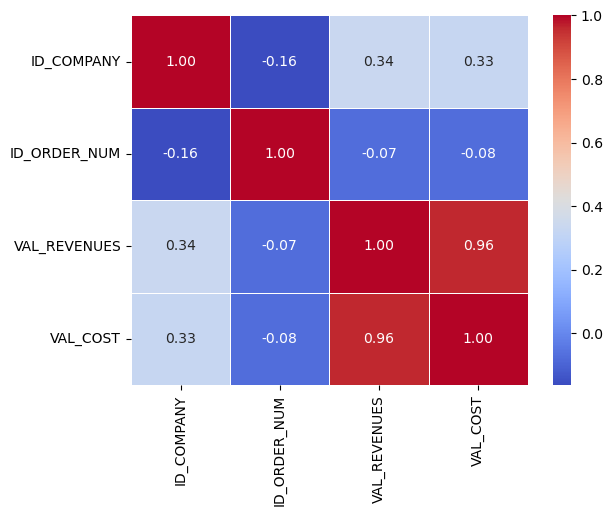

In [11]:
print_matrix(df)

# -----------------------------
# 3. FEATURE ENGINEERING
# -----------------------------

In [12]:
df_ml = prepare_features(df)

# -----------------------------
# 4. TRAIN/TEST SPLIT PER ANNO
# -----------------------------

In [13]:
split_idx = int(len(df_ml) * 0.8)

train = df_ml.iloc[:split_idx]
test = df_ml.iloc[split_idx:]

x_train = train.drop(columns=["VAL_REVENUES"])
y_train = train["VAL_REVENUES"]

x_test = test.drop(columns=["VAL_REVENUES"])
y_test = test["VAL_REVENUES"]

# -----------------------------
# 5. CREAZIONE MODELLO LINEARE
# -----------------------------

In [14]:
# TRASFORMAZIONE TARGET (LOG)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# RIMOZIONE DUMMY RARE
x_train, x_test, dropped_cols = drop_rare_dummies_train_test(x_train, x_test)

# SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# MODELLO LINEARE
model = LinearRegression()
model.fit(x_train_scaled, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# -----------------------------
# 6. PREDIZIONE E METRICHE
# -----------------------------

In [15]:
y_pred_log = model.predict(x_test_scaled)
y_pred = np.expm1(y_pred_log)  # inversione log

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}, R2: {r2}")

# COEFFICIENTI
coeff_df = pd.DataFrame(model.coef_, index=x_train.columns, columns=['Peso_Variabile'])
print(coeff_df.sort_values(by='Peso_Variabile', ascending=False))

MAE: 3828.919349421152, R2: 0.5876383994261383
                          Peso_Variabile
GIORNO                          0.305448
ID_COUNTRY_US                   0.290754
ID_AREA_MANAGER_4D6             0.162062
ID_BUSINESS_LINE_4C7            0.159214
IDS_ITEM_7270011-W401MAG        0.095264
...                                  ...
GIORNO_SIN                     -0.069797
IDS_ITEM_7488255-W401MAG       -0.085905
IDS_ITEM_7245492-W401MAG       -0.099519
MESE_COS                       -0.109861
MESE                           -0.326179

[67 rows x 1 columns]


In [16]:
df_future = make_forecast(
    start_date="2027-01-01",
    end_date="2027-12-31",
    df_old = df
)

In [17]:
# Aggiungo colonne mancanti
missing_cols = set(x_train.columns) - set(df_future.columns)
for col in missing_cols:
    df_future[col] = 0

# Rimuovo colonne extra
df_future = df_future[x_train.columns]

df_future_scaled = scaler.transform(df_future)
pred_log = model.predict(df_future_scaled)
df_future["PREDICTED_REVENUE"] = np.expm1(pred_log)

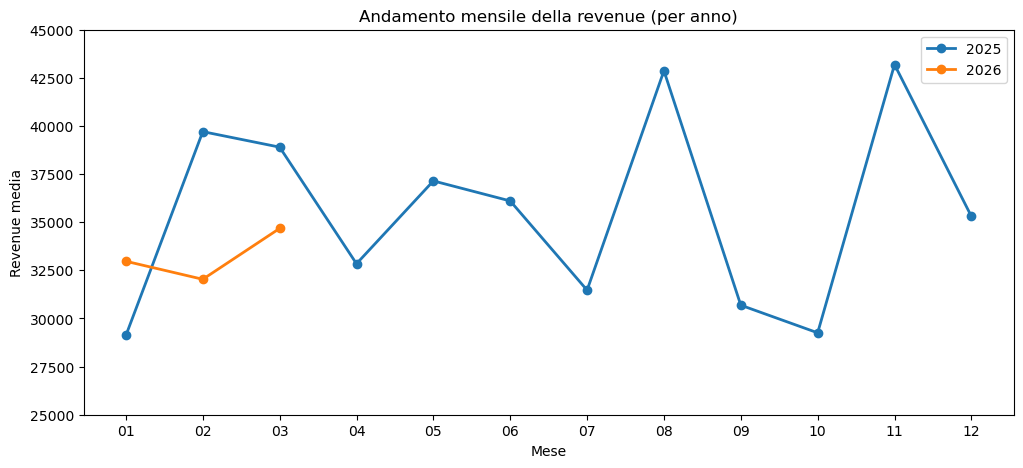

In [18]:
plot_trend(df_ml, revenue_col="VAL_REVENUES")

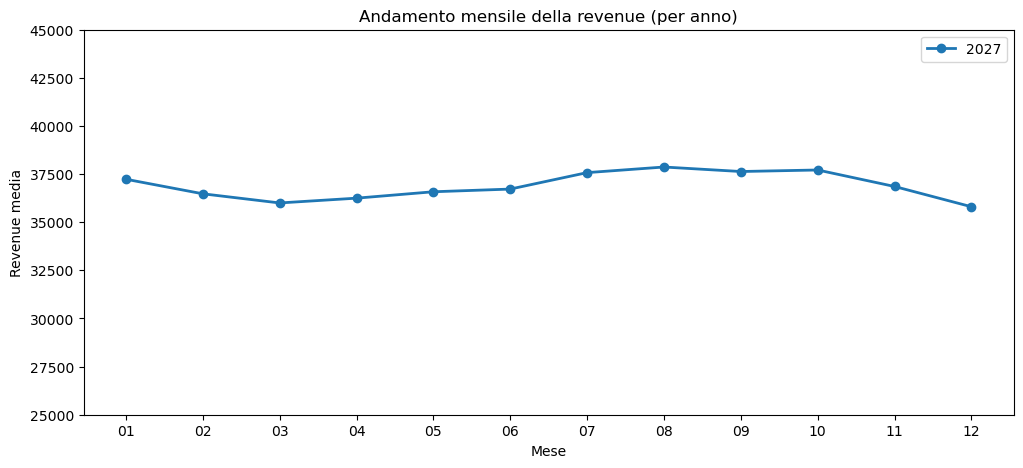

In [19]:
plot_trend(df_future, revenue_col="PREDICTED_REVENUE")